# VW Price Prediction - XGBoost

Let's start by importing necessary packages.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

Now read in the dataframe and prepare it for use with `XGBoost`.

In [3]:
df = pd.read_parquet("../all_car_details_cleaned.parquet")

## Preparing Data for XGBoost

Let's first drop useless columns.

In [5]:
columns_to_drop = [
    "url",
    "num_images",
    "general_inspection",
    "emission_class",
    "comfort_and_convenience",
    "safety_and_security",
    "entertainment_and_media",
    "extras",
    "paint",
]


df.drop(columns=columns_to_drop, errors="ignore", inplace=True)

Let's only keep VW branded cars.

In [9]:
df = df[df["make"] == "volkswagen"]
df = df.drop("make", axis=1)
df["car_title"].value_counts()

car_title
Volkswagen Golf              3636
Volkswagen Polo              2819
Volkswagen Golf GTI          1278
Volkswagen Tiguan            1242
Volkswagen Passat Variant    1236
                             ... 
Volkswagen T7 California        1
Skoda Citigo                    1
Volkswagen T3 Blue Star         1
Volkswagen Polo Sedan           1
Volkswagen Polo Variant         1
Name: count, Length: 108, dtype: int64

Looks good, there are only `108` titles, this is one hot encodable still.

Now since XGBoost does not need any scaling, imputing of missing values or turning to tensors, let's start by splitting to ensure no data leakage happens and then split the dataset before applying grouping and OHE.

In [10]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# --- 6. Preprocessing with ColumnTransformer and Pipeline ---
# XGBoost handles NaNs in numerical features. For categorical, OHE needs a strategy.
# We can impute categorical NaNs with a placeholder like 'Missing' before OHE.

# Create a list of transformers
# For OHE, handle_unknown='ignore' will assign all zeros to categories encountered in test but not in train.
# If NaNs are present in categorical columns, OneHotEncoder will raise an error by default.
# We should fill them or use a specific strategy.
# Let's fill NaNs in categorical columns before OHE for simplicity here.
print("Filling NaNs in categorical features with 'Missing_Cat_Value'...")
categorical_features = [col for col in X_train.select_dtypes(include=['object', 'category']).columns]
for col in categorical_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna('Missing_Cat_Value')
    if col in X_test.columns:
        X_test[col] = X_test[col].fillna('Missing_Cat_Value')
        
print("NaNs filled in categorical features.")


# Define the ColumnTransformer
# Numerical features will pass through as XGBoost handles their NaNs and doesn't require scaling.
# If you had numerical features needing imputation/scaling, you'd add a ('num', SimpleImputer/StandardScaler, numerical_features)
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop=None), categorical_features)
    ],
    remainder='passthrough'  # Keep numerical columns not specified in transformers
)
print("Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.")

# Fit the preprocessor on X_train_processed and transform both
X_train_final = preprocessor.fit_transform(X_train)
print("Preprocessor fitted and transformed X_train.")
print(f"Type of X_train_final: {type(X_train_final)}") # Should be <class 'scipy.sparse._csr.csr_matrix'> or similar
print(f"Shape of sparse X_train_final: {X_train_final.shape}")

X_test_final = preprocessor.transform(X_test)
print("X_test transformed using the fitted preprocessor.")
print(f"Shape of sparse X_test_final: {X_test_final.shape}")

# Get feature names after OHE for DMatrix or if you want to convert back to DataFrame
# This can be a bit tricky with ColumnTransformer and passthrough.
# Method 1: Get feature names from OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(categorical_features)

# Method 2: Construct full list of names
original_cols = X_train.columns.tolist() # Ensure this is defined if not already
passthrough_feature_names = [col for col in original_cols if col not in categorical_features]
final_feature_names = list(ohe_feature_names) + passthrough_feature_names
print("Feature names after OHE and passthrough:", final_feature_names)
    
print(f"Number of features after OHE: {len(final_feature_names)}")
# Display some info
# print("\nFirst 5 rows of X_train_final_df:")
# print(X_train_final_df.head())
# print("\nInfo of X_train_final_df:")
# X_train_final_df.info()

Filling NaNs in categorical features with 'Missing_Cat_Value'...
NaNs filled in categorical features.
Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.
Preprocessor fitted and transformed X_train.
Type of X_train_final: <class 'scipy.sparse._csr.csr_matrix'>
Shape of sparse X_train_final: (20077, 259)
X_test transformed using the fitted preprocessor.
Shape of sparse X_test_final: (5020, 259)
Feature names after OHE and passthrough: ['car_title_Skoda Citigo', 'car_title_Volkswagen', 'car_title_Volkswagen 181', 'car_title_Volkswagen Amarok', 'car_title_Volkswagen Arteon', 'car_title_Volkswagen Atlas', 'car_title_Volkswagen Beetle', 'car_title_Volkswagen Bora', 'car_title_Volkswagen Buggy', 'car_title_Volkswagen Bus', 'car_title_Volkswagen CC', 'car_title_Volkswagen Caddy', 'car_title_Volkswagen Coccinelle', 'car_title_Volkswagen Corrado', 'car_title_Volkswagen Crafter', 'car_title_Volkswagen Cross Touran', 'car_title_Volkswagen Derby

In [12]:
# --- 7. Prepare DMatrix for XGBoost ---
# XGBoost DMatrix can directly handle scipy sparse matrices
dtrain = xgb.DMatrix(X_train_final, label=y_train, feature_names=final_feature_names)
dtest = xgb.DMatrix(X_test_final, label=y_test, feature_names=final_feature_names)

print("DMatrix created successfully from sparse data.")

DMatrix created successfully from sparse data.


## Train XGBoost

In [13]:
# --- 8. Train a Baseline XGBoost Model ---
print("--- Training Baseline XGBoost Model ---")

# Define baseline parameters
# These are just starting points
params = {
    'objective': 'reg:squarederror',  # For regression tasks, predicts the squared error
    'eval_metric': ['rmse', 'mae'],   # Evaluation metrics: Root Mean Squared Error, Mean Absolute Error
    'eta': 0.1,                       # Learning rate (alias: learning_rate)
    'max_depth': 6,                   # Maximum depth of a tree
    'subsample': 0.8,                 # Subsample ratio of the training instances
    'colsample_bytree': 0.8,          # Subsample ratio of columns when constructing each tree
    'seed': 42                        # For reproducibility
}

num_boost_round = 100  # Number of boosting rounds (trees to build)

# Set up a watchlist to monitor performance on the test set during training
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

print(f"Starting training with {num_boost_round} rounds...")
bst_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    early_stopping_rounds=10,  # Stop if performance on eval set doesn't improve for 10 rounds
    verbose_eval=10            # Print evaluation metrics every 10 rounds
)

print("Baseline model training complete.")

--- Training Baseline XGBoost Model ---
Starting training with 100 rounds...
[0]	train-rmse:157915.24956	train-mae:128791.50074	eval-rmse:159297.86605	eval-mae:130048.64016
[10]	train-rmse:89943.34283	train-mae:68820.47721	eval-rmse:93206.05171	eval-mae:70881.09689
[20]	train-rmse:71804.34841	train-mae:47159.10503	eval-rmse:77775.99483	eval-mae:50486.78163
[30]	train-rmse:66542.94803	train-mae:39537.07269	eval-rmse:73991.21651	eval-mae:43508.12966
[40]	train-rmse:63991.13550	train-mae:36748.35539	eval-rmse:72961.24291	eval-mae:41294.57016
[50]	train-rmse:62371.92532	train-mae:35411.95081	eval-rmse:72349.69552	eval-mae:40312.48695
[60]	train-rmse:61085.26064	train-mae:34544.59860	eval-rmse:72201.42147	eval-mae:39855.22742
[70]	train-rmse:60139.42468	train-mae:33906.13802	eval-rmse:72075.86804	eval-mae:39547.26145
[80]	train-rmse:59317.23425	train-mae:33456.59772	eval-rmse:71913.85630	eval-mae:39324.66013
[90]	train-rmse:58655.89534	train-mae:33124.42910	eval-rmse:71820.17185	eval-mae:39

In [14]:
# --- 9. Make Predictions and Evaluate Baseline Model ---
print("--- Evaluating Baseline Model ---")
y_pred_baseline = bst_model.predict(dtest)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f"Baseline Model - Test Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_baseline:.4f}")
print(f"  R-squared (R2): {r2_baseline:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_baseline:.4f}")

# You can also access the best score and iteration if early stopping occurred
print(f"Best MAE on eval set during training: {bst_model.best_score:.4f} at iteration {bst_model.best_iteration+1}")

--- Evaluating Baseline Model ---
Baseline Model - Test Set Performance:
  Mean Absolute Error (MAE): 39168.0370
  R-squared (R2): 0.8224
  Root Mean Squared Error (RMSE): 71871.0408
Best MAE on eval set during training: 39159.2485 at iteration 99


--- Feature Importance (Baseline Model) ---


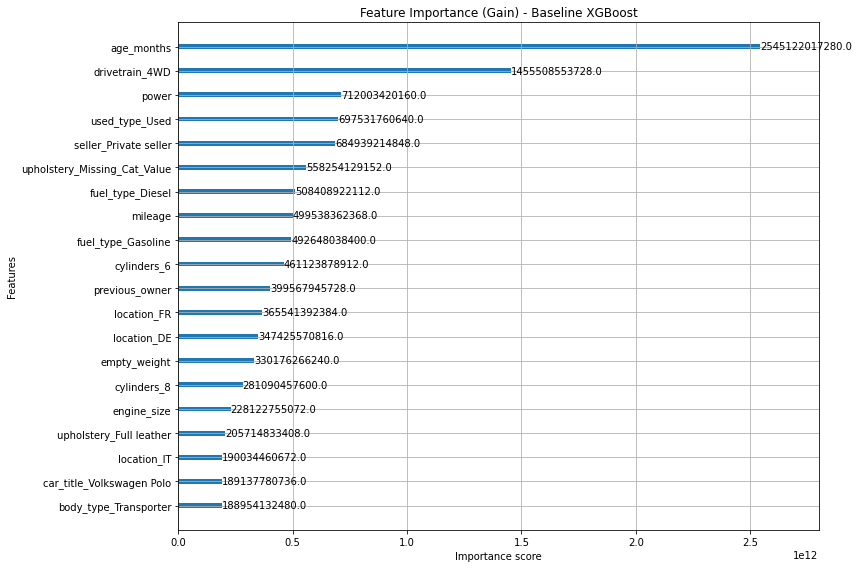

Top 10 features by gain: [('age_months', 2545122017280.0), ('drivetrain_4WD', 1455508553728.0), ('power', 712003420160.0), ('used_type_Used', 697531760640.0), ('seller_Private seller', 684939214848.0), ('upholstery_Missing_Cat_Value', 558254129152.0), ('fuel_type_Diesel', 508408922112.0), ('mileage', 499538362368.0), ('fuel_type_Gasoline', 492648038400.0), ('cylinders_6', 461123878912.0)]


In [15]:
# --- 10. Feature Importance (Optional but useful) ---
print("--- Feature Importance (Baseline Model) ---")
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8)) # Adjust height based on num features
xgb.plot_importance(bst_model, ax=ax, max_num_features=20, importance_type='gain') # Show top 20 features by gain
plt.title("Feature Importance (Gain) - Baseline XGBoost")
plt.tight_layout()
plt.show()

# You can also get importance as a dictionary
# importance_types: 'weight', 'gain', 'cover', 'total_gain', 'total_cover'
# 'gain' is often a good default for feature contribution.
feature_importance_gain = bst_model.get_score(importance_type='gain')
print("Top 10 features by gain:", sorted(feature_importance_gain.items(), key=lambda item: item[1], reverse=True)[:10])

It seems like unsurprisingly the make and car_title were the most significant predictors by feature importance.

## Hyperparameter Tuning

In [42]:
# Example using RandomizedSearchCV (conceptual)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import uniform, randint

xgb_reg = XGBRegressor(
    objective="reg:squarederror", seed=42, eval_metric="mae", early_stopping_rounds=10
)

param_dist = {
    # Core Parameters
    "n_estimators": randint(100, 2000),  # Wider range to explore
    "learning_rate": uniform(0.01, 0.3),  # Continuous range for finer tuning
    "max_depth": randint(3, 15),  # Deeper trees but with constraints
    "min_child_weight": randint(1, 10),  # Controls overfitting in leaf nodes
    # Regularization
    "gamma": uniform(0, 0.5),  # Minimum loss reduction for splits
    "reg_alpha": uniform(0, 1),  # L1 regularization (xgb's alpha)
    "reg_lambda": uniform(0, 1),  # L2 regularization (xgb's lambda)
    # Subsampling
    "subsample": uniform(0.6, 0.4),  # Range: 0.6-1.0
    "colsample_bytree": uniform(0.6, 0.4),  # Range: 0.6-1.0
    "colsample_bylevel": uniform(0.6, 0.4),  # Range: 0.6-1.0
    "colsample_bynode": uniform(0.6, 0.4),  # Range: 0.6-1.0
}

# RandomizedSearchCV with expanded settings
search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=50,  # Start with 50 iterations for Stage 1
    cv=3,  # Fewer folds for speed; increase to 5 for final runs
    scoring="neg_mean_absolute_error",  # Primary metric
    refit=True,
    random_state=42,
    verbose=2,
    n_jobs=-1,  # Parallelize searches
)

# Fit on subset (Stage 1)
subset_size = int(0.2 * X_train_final.shape[0])
X_subset, y_subset = X_train_final[:subset_size], y_train[:subset_size]

print("Starting Stage 1: Broad exploration on subset...")
search.fit(
    X_subset,
    y_subset,
    eval_set=[(X_test_final, y_test)],  # Early stopping on test set
    verbose=True,
)

# Save best params for Stage 2
stage1_best = search.best_params_
print(f"Stage 1 Best Params: {stage1_best}")

Starting Stage 1: Broad exploration on subset...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[0]	validation_0-mae:137561.76515
[1]	validation_0-mae:136534.94290
[2]	validation_0-mae:135541.17347
[3]	validation_0-mae:134536.30264
[4]	validation_0-mae:133570.01683
[5]	validation_0-mae:132593.99189
[6]	validation_0-mae:131662.56472
[7]	validation_0-mae:130810.69293
[8]	validation_0-mae:129965.68775
[9]	validation_0-mae:129024.15292
[10]	validation_0-mae:128089.70665
[11]	validation_0-mae:127191.21159
[12]	validation_0-mae:126274.98347
[13]	validation_0-mae:125400.94222
[14]	validation_0-mae:124504.03056
[15]	validation_0-mae:123645.34131
[16]	validation_0-mae:122798.95199
[17]	validation_0-mae:121948.86366
[18]	validation_0-mae:121106.62514
[19]	validation_0-mae:120321.43750
[20]	validation_0-mae:119480.29813
[21]	validation_0-mae:118652.13417
[22]	validation_0-mae:117841.45791
[23]	validation_0-mae:117053.89640
[24]	validation_0-mae:116260.82560
[25]	validation_0-mae:11

In [44]:
final_model = XGBRegressor(
    **stage1_best,
    objective="reg:squarederror",
    eval_metric="mae",
    early_stopping_rounds=10
)

final_model.fit(X_train_final, y_train, eval_set=[(X_test_final, y_test)], verbose=True)
results = final_model.evals_result()

[0]	validation_0-mae:137901.74744
[1]	validation_0-mae:136831.37834
[2]	validation_0-mae:135777.83791
[3]	validation_0-mae:134723.23535
[4]	validation_0-mae:133683.48189
[5]	validation_0-mae:132654.55985
[6]	validation_0-mae:131636.37066
[7]	validation_0-mae:130644.84401
[8]	validation_0-mae:129643.41200
[9]	validation_0-mae:128648.90570
[10]	validation_0-mae:127740.69111
[11]	validation_0-mae:126773.28725
[12]	validation_0-mae:125820.61461
[13]	validation_0-mae:124860.65317
[14]	validation_0-mae:123914.25082
[15]	validation_0-mae:122998.51425
[16]	validation_0-mae:122129.49132
[17]	validation_0-mae:121228.52893
[18]	validation_0-mae:120326.61339
[19]	validation_0-mae:119441.19697
[20]	validation_0-mae:118572.02747
[21]	validation_0-mae:117751.29297
[22]	validation_0-mae:116881.84006
[23]	validation_0-mae:116031.91226
[24]	validation_0-mae:115183.62639
[25]	validation_0-mae:114403.30956
[26]	validation_0-mae:113621.98363
[27]	validation_0-mae:112816.87603
[28]	validation_0-mae:112016.2

The best parameters from these were seemingly always the more fine grained detailed ones.

## Analyze Results

Let's plot the MAEs to see if it is worth to train for more rounds.

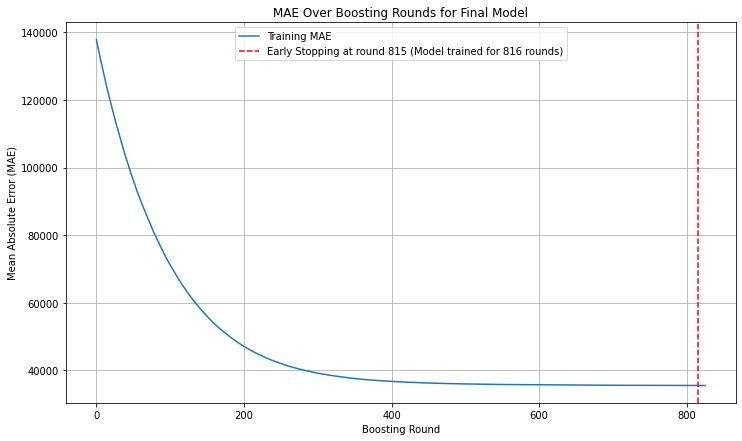

The model was trained for 816 rounds.
The best MAE achieved on the test set during training was: 35461.89


In [48]:
# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history = results['validation_0']['mae']
# test_mae_history = results['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history, label='Training MAE')
# plt.plot(test_mae_history, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds = final_model.best_iteration + 1
plt.axvline(final_model.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model.best_iteration} (Model trained for {actual_rounds} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model.best_score:.2f}")

In [49]:
# Predictions
y_train_pred = final_model.predict(X_train_final)
y_test_pred = final_model.predict(X_test_final)

# Training set metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)  # MSE added
train_r2 = r2_score(y_train, y_train_pred)

# Test set metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)     # MSE added
test_r2 = r2_score(y_test, y_test_pred)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

Training Metrics:
MAE: 13767.5432, MSE: 643325737.8900, R²: 0.9776

Test Metrics:
MAE: 35461.8913, MSE: 4882076303.0172, R²: 0.8321


We can see that by 500 rounds the model is almost starting to overfit as the Training MAE and Test MAE diverge, the Test one flattens out more. Let's for good measure try and run it until 1000 with a max depth of 9 to see if it overfits.

In [20]:
best_params_1000 = {
    'subsample': 0.8,
    'n_estimators': 1000,
    'min_child_weight': 5,
    'max_depth': 9,
    'learning_rate': 0.1,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
final_model_1000 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=10,
    **best_params_1000  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training_1000 = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model_1000.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training_1000,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")


Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:128242.51126	validation_1-mae:129648.87169
[1]	validation_0-mae:118392.89610	validation_1-mae:120131.40584
[2]	validation_0-mae:109431.01705	validation_1-mae:111530.76509
[3]	validation_0-mae:101413.84773	validation_1-mae:103919.86649
[4]	validation_0-mae:94111.27050	validation_1-mae:96925.04782
[5]	validation_0-mae:87667.12706	validation_1-mae:90782.00643
[6]	validation_0-mae:81796.09487	validation_1-mae:85144.60108
[7]	validation_0-mae:76546.11108	validation_1-mae:80101.31227
[8]	validation_0-mae:71659.66148	validation_1-mae:75518.40162
[9]	validation_0-mae:67255.60030	validation_1-mae:71438.77717
[10]	validation_0-mae:63258.96763	validation_1-mae:67787.85097
[11]	validation_0-mae:59667.51917	validation_1-mae:64415.66452
[12]	validation_0-mae:56369.80210	validation_1-mae:61475.38246
[13]	validation_0-mae:53509.49343	validation_1-mae:58902.24227
[14]	validation_0-mae:50926.45349	validation_1-

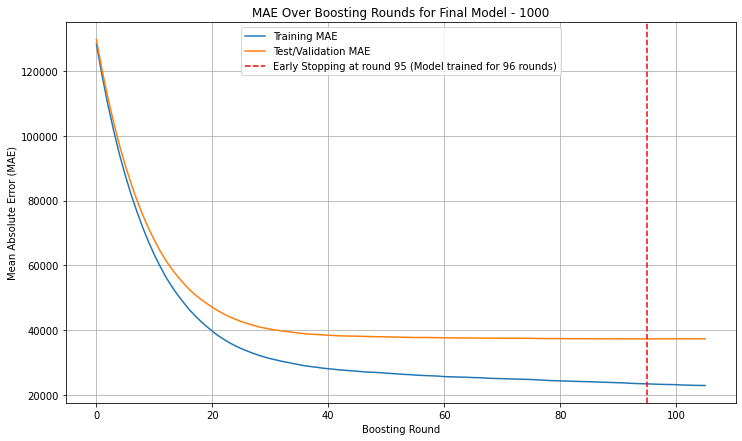

The model was trained for 96 rounds.
The best MAE achieved on the test set during training was: 37329.20


In [21]:
# Retrieve the evaluation results
results_1000 = final_model_1000.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_1000 = results_1000['validation_0']['mae']
test_mae_history_1000 = results_1000['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_1000, label='Training MAE')
plt.plot(test_mae_history_1000, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_1000 = final_model_1000.best_iteration + 1
plt.axvline(final_model_1000.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model_1000.best_iteration} (Model trained for {actual_rounds_1000} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - 1000')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_1000} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model_1000.best_score:.2f}")

In [22]:
# Predictions
y_train_pred_1000 = final_model_1000.predict(X_train_final)
y_test_pred_1000 = final_model_1000.predict(X_test_final)

# Training set metrics
train_mae_1000 = mean_absolute_error(y_train, y_train_pred_1000)
train_mse_1000 = mean_squared_error(y_train, y_train_pred_1000)  # MSE added
train_r2_1000 = r2_score(y_train, y_train_pred_1000)

# Test set metrics
test_mae_1000 = mean_absolute_error(y_test, y_test_pred_1000)
test_mse_1000 = mean_squared_error(y_test, y_test_pred_1000)     # MSE added
test_r2_1000 = r2_score(y_test, y_test_pred_1000)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_1000:.4f}, MSE: {train_mse_1000:.4f}, R²: {train_r2_1000:.4f}")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_1000:.4f}, MSE: {test_mse_1000:.4f}, R²: {test_r2_1000:.4f}")

Training Metrics:
MAE: 23447.2440, MSE: 1774594297.1196, R²: 0.9382

Test Metrics:
MAE: 37329.1989, MSE: 5089164868.1769, R²: 0.8250


This amount of extra training seems to havepaid off, meanwhile the R2 is much higher for the training set, the test ever sos slightly improved from 0.76 to 0.774. Let's try an even higher round of 2000 and max depth of 12 to see where the point is where it is no longer worth.

In [23]:
best_params_2000 = {
    'subsample': 0.8,
    'n_estimators': 2000,
    'min_child_weight': 5,
    'max_depth': 12,
    'learning_rate': 0.1,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
final_model_2000 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=10,
    **best_params_2000  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training_2000 = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model_2000.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training_2000,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")

Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:127534.98940	validation_1-mae:129396.13401
[1]	validation_0-mae:117311.28203	validation_1-mae:119745.00694
[2]	validation_0-mae:108010.68162	validation_1-mae:111026.55117
[3]	validation_0-mae:99608.74113	validation_1-mae:103316.71450
[4]	validation_0-mae:92028.34223	validation_1-mae:96349.52293
[5]	validation_0-mae:85241.98651	validation_1-mae:90157.41910
[6]	validation_0-mae:79036.82414	validation_1-mae:84486.53690
[7]	validation_0-mae:73479.75123	validation_1-mae:79414.38216
[8]	validation_0-mae:68388.41302	validation_1-mae:74795.62046
[9]	validation_0-mae:63737.64838	validation_1-mae:70685.24847
[10]	validation_0-mae:59561.81718	validation_1-mae:66977.28134
[11]	validation_0-mae:55786.33084	validation_1-mae:63520.74248
[12]	validation_0-mae:52270.35376	validation_1-mae:60528.06191
[13]	validation_0-mae:49182.98822	validation_1-mae:57926.30259
[14]	validation_0-mae:46389.99302	validation_1-m

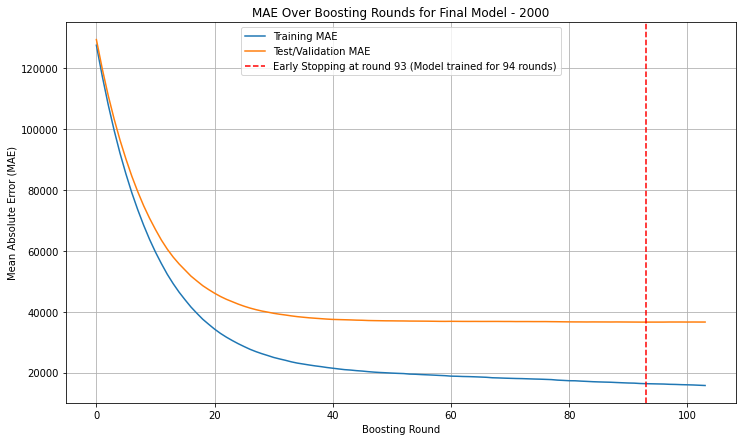

The model was trained for 94 rounds.
The best MAE achieved on the test set during training was: 37329.20


In [24]:
# Retrieve the evaluation results
results_2000 = final_model_2000.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_2000 = results_2000['validation_0']['mae']
test_mae_history_2000 = results_2000['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_2000, label='Training MAE')
plt.plot(test_mae_history_2000, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_2000 = final_model_2000.best_iteration + 1
plt.axvline(final_model_2000.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model_2000.best_iteration} (Model trained for {actual_rounds_2000} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - 2000')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_2000} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model_1000.best_score:.2f}")

In [25]:
# Predictions
y_train_pred_2000 = final_model_2000.predict(X_train_final)
y_test_pred_2000 = final_model_2000.predict(X_test_final)

# Training set metrics
train_mae_2000 = mean_absolute_error(y_train, y_train_pred_2000)
train_mse_2000 = mean_squared_error(y_train, y_train_pred_2000)  # MSE added
train_r2_2000 = r2_score(y_train, y_train_pred_2000)

# Test set metrics
test_mae_2000 = mean_absolute_error(y_test, y_test_pred_2000)
test_mse_2000 = mean_squared_error(y_test, y_test_pred_2000)     # MSE added
test_r2_2000 = r2_score(y_test, y_test_pred_2000)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_2000:.4f}, MSE: {train_mse_2000:.4f}, R²: {train_r2_2000:.4f}")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_2000:.4f}, MSE: {test_mse_2000:.4f}, R²: {test_r2_2000:.4f}")

Training Metrics:
MAE: 16336.3794, MSE: 875360673.7302, R²: 0.9695

Test Metrics:
MAE: 36568.0302, MSE: 5143276575.2001, R²: 0.8231


While this has probably overfitted more, we can see that it stopped early and we had better results all around. Let's just try one more of 2000 rounds max but with deeper max depth.

In [26]:
best_params_2000_deep = {
    'subsample': 0.8,
    'n_estimators': 2000,
    'min_child_weight': 5,
    'max_depth': 22,
    'learning_rate': 0.1,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
final_model_2000_deep = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=10,
    **best_params_2000_deep  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training_2000_deep = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model_2000_deep.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training_2000_deep,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")

Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:126998.57448	validation_1-mae:129353.98861
[1]	validation_0-mae:116511.27780	validation_1-mae:119749.62503
[2]	validation_0-mae:107011.66043	validation_1-mae:111035.13681
[3]	validation_0-mae:98379.72688	validation_1-mae:103290.25136
[4]	validation_0-mae:90535.57440	validation_1-mae:96289.22045
[5]	validation_0-mae:83449.31773	validation_1-mae:90001.20836
[6]	validation_0-mae:77025.65562	validation_1-mae:84269.06123
[7]	validation_0-mae:71231.86103	validation_1-mae:79177.16982
[8]	validation_0-mae:65925.25088	validation_1-mae:74662.56638
[9]	validation_0-mae:61039.11200	validation_1-mae:70513.31243
[10]	validation_0-mae:56573.87409	validation_1-mae:66697.01869
[11]	validation_0-mae:52607.43730	validation_1-mae:63354.62534
[12]	validation_0-mae:48962.98907	validation_1-mae:60364.37009
[13]	validation_0-mae:45613.68496	validation_1-mae:57692.27765
[14]	validation_0-mae:42614.12948	validation_1-m

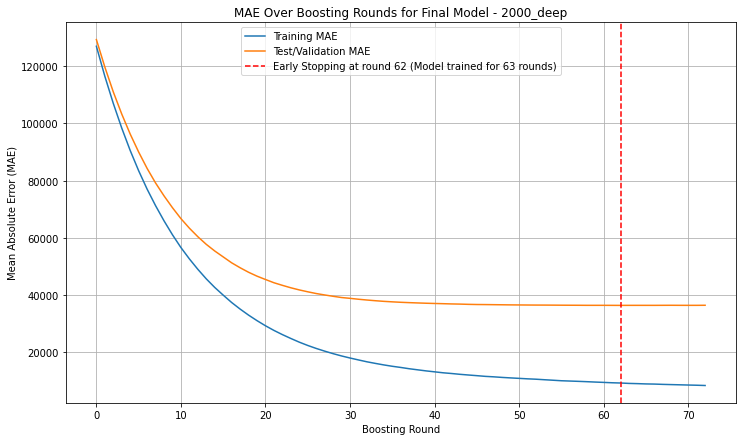

The model was trained for 63 rounds.
The best MAE achieved on the test set during training was: 37329.20


In [27]:
# Retrieve the evaluation results
results_2000_deep = final_model_2000_deep.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_2000_deep = results_2000_deep['validation_0']['mae']
test_mae_history_2000_deep = results_2000_deep['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_2000_deep, label='Training MAE')
plt.plot(test_mae_history_2000_deep, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_2000_deep = final_model_2000_deep.best_iteration + 1
plt.axvline(final_model_2000_deep.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model_2000_deep.best_iteration} (Model trained for {actual_rounds_2000_deep} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - 2000_deep')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_2000_deep} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model_1000.best_score:.2f}")

In [28]:
# Predictions
y_train_pred_2000_deep = final_model_2000_deep.predict(X_train_final)
y_test_pred_2000_deep = final_model_2000_deep.predict(X_test_final)

# Training set metrics
train_mae_2000_deep = mean_absolute_error(y_train, y_train_pred_2000_deep)
train_mse_2000_deep = mean_squared_error(y_train, y_train_pred_2000_deep)  # MSE added
train_r2_2000_deep = r2_score(y_train, y_train_pred_2000_deep)

# Test set metrics
test_mae_2000_deep = mean_absolute_error(y_test, y_test_pred_2000_deep)
test_mse_2000_deep = mean_squared_error(y_test, y_test_pred_2000_deep)     # MSE added
test_r2_2000_deep = r2_score(y_test, y_test_pred_2000_deep)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_2000_deep:.4f}, MSE: {train_mse_2000_deep:.4f}, R²: {train_r2_2000_deep:.4f}")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_2000_deep:.4f}, MSE: {test_mse_2000_deep:.4f}, R²: {test_r2_2000_deep:.4f}")

Training Metrics:
MAE: 9176.4405, MSE: 303156858.9309, R²: 0.9894

Test Metrics:
MAE: 36337.9440, MSE: 5117603485.6859, R²: 0.8240


This seems to be the best so far, but let's try and tweak it a bit so that it does not overfit as much.

In [29]:
best_params_underfit = {
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'n_estimators': 3000,
    'min_child_weight': 5,
    'max_depth': 20,
    'learning_rate': 0.01,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1
}

# Initialize and train the final model
final_model_underfit = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=15,
    **best_params_underfit  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training_underfit = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model_underfit.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training_underfit,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")

Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:136762.23415	validation_1-mae:137945.15575
[1]	validation_0-mae:135616.88794	validation_1-mae:136887.97636
[2]	validation_0-mae:134489.06837	validation_1-mae:135825.01457
[3]	validation_0-mae:133361.80954	validation_1-mae:134789.29699
[4]	validation_0-mae:132258.09682	validation_1-mae:133789.33574
[5]	validation_0-mae:131158.36321	validation_1-mae:132782.13050
[6]	validation_0-mae:130068.10259	validation_1-mae:131771.96019
[7]	validation_0-mae:128993.66557	validation_1-mae:130781.72179
[8]	validation_0-mae:127915.37299	validation_1-mae:129793.38871
[9]	validation_0-mae:126928.30352	validation_1-mae:128902.54404
[10]	validation_0-mae:125865.91960	validation_1-mae:127956.46571
[11]	validation_0-mae:124839.94242	validation_1-mae:127031.35921
[12]	validation_0-mae:123817.03554	validation_1-mae:126101.18846
[13]	validation_0-mae:122851.55762	validation_1-mae:125240.96979
[14]	validation_0-mae:12184

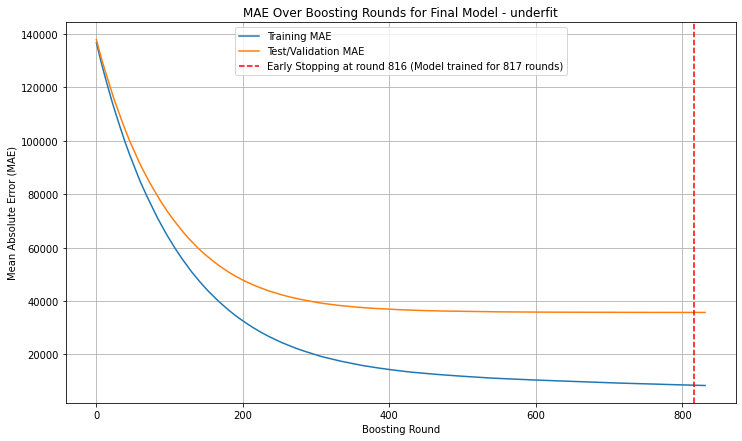

The model was trained for 817 rounds.
The best MAE achieved on the test set during training was: 37329.20


In [30]:
# Retrieve the evaluation results
results_underfit = final_model_underfit.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_underfit = results_underfit['validation_0']['mae']
test_mae_history_underfit = results_underfit['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_underfit, label='Training MAE')
plt.plot(test_mae_history_underfit, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_underfit = final_model_underfit.best_iteration + 1
plt.axvline(final_model_underfit.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model_underfit.best_iteration} (Model trained for {actual_rounds_underfit} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - underfit')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_underfit} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model_1000.best_score:.2f}")

In [31]:
# Predictions
y_train_pred_underfit = final_model_underfit.predict(X_train_final)
y_test_pred_underfit = final_model_underfit.predict(X_test_final)

# Training set metrics
train_mae_underfit = mean_absolute_error(y_train, y_train_pred_underfit)
train_mse_underfit = mean_squared_error(y_train, y_train_pred_underfit)  # MSE added
train_r2_underfit = r2_score(y_train, y_train_pred_underfit)

# Test set metrics
test_mae_underfit = mean_absolute_error(y_test, y_test_pred_underfit)
test_mse_underfit = mean_squared_error(y_test, y_test_pred_underfit)     # MSE added
test_r2_underfit = r2_score(y_test, y_test_pred_underfit)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_underfit:.4f}, MSE: {train_mse_underfit:.4f}, R²: {train_r2_underfit:.4f}")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_underfit:.4f}, MSE: {test_mse_underfit:.4f}, R²: {test_r2_underfit:.4f}")

Training Metrics:
MAE: 8490.7918, MSE: 260848128.6913, R²: 0.9909

Test Metrics:
MAE: 35747.3092, MSE: 4956616019.6742, R²: 0.8295


This took a very long time, seems like this is the best we can get it for now.

### Predicted VS Actual - Residual Plots

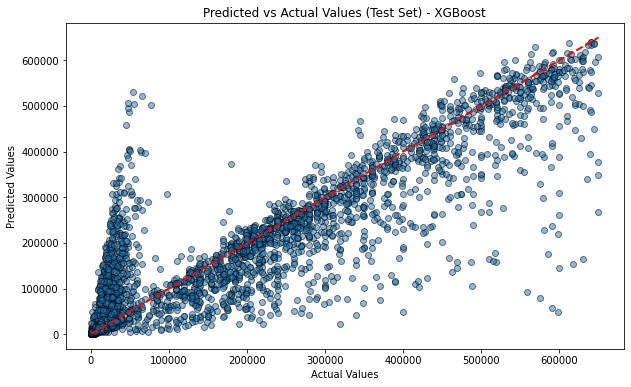

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_underfit, alpha=0.5, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values (Test Set) - XGBoost")
plt.show()

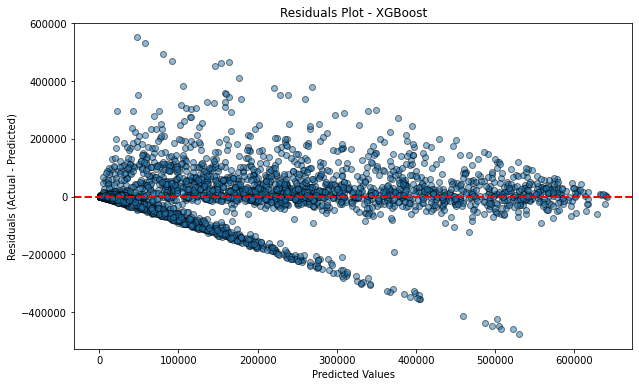

In [33]:
residuals = y_test - y_test_pred_underfit

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_underfit, residuals, alpha=0.5, edgecolors="k")
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot - XGBoost")
plt.show()

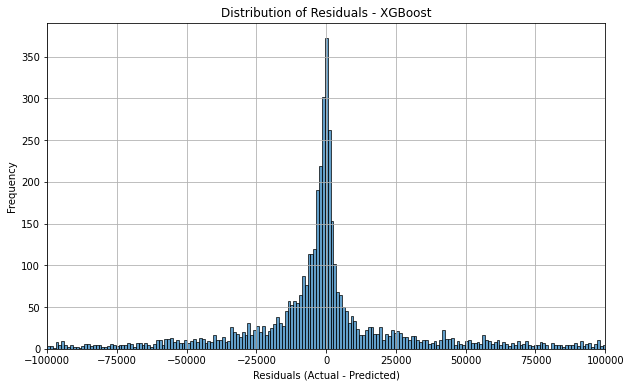

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=1000, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals - XGBoost')
plt.grid(True)
plt.xlim(-100000, 100000)
plt.show()

### Feature Importance

<Figure size 720x576 with 0 Axes>

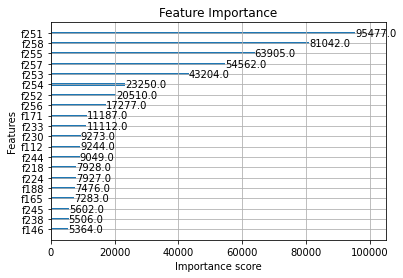

In [38]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(final_model_underfit, max_num_features=20)
plt.title("Feature Importance")
plt.show()